---
**GUIA DE LABORATORIO 9 - Regresión Lineal en Dos Caminos**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt

INDIGO, PURPURA, CORAL, TINTA = '#4F46E5', '#7E22CE', '#F43F5E', '#111827'
plt.rcParams.update({'figure.figsize': (7, 4.2),
                    'axes.grid': True, 'grid.alpha': 0.3,
                    'axes.spines.top': False,
                    'axes.spines.right': False})

In [4]:
rng = np.random.default_rng(42)
m = 60

horas = rng.uniform(0, 10, m)
nota  = 30 + 5 * horas + rng.normal(0, 5, m)
print('Primeras 5 muestras:')
for h, n in zip(horas[:5], nota[:5]):
  print(f'  horas = {h:5.2f}   nota = {n:6.2f}')

Primeras 5 muestras:
  horas =  7.74   nota =  64.37
  horas =  4.39   nota =  56.79
  horas =  8.59   nota =  64.52
  horas =  6.97   nota =  63.19
  horas =  0.94   nota =  35.52


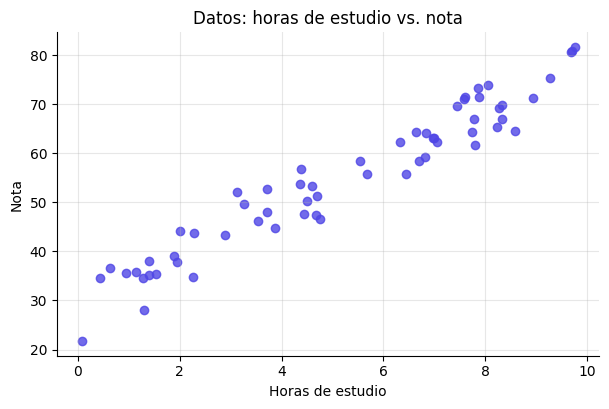

In [5]:
plt.scatter(horas, nota, color=INDIGO, alpha=0.8)
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Datos: horas de estudio vs. nota')
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score)

X = horas.reshape(-1, 1)
y = nota

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)
print('Entrenamiento:', X_train.shape, '  Prueba:', X_test.shape)

Entrenamiento: (48, 1)   Prueba: (12, 1)


In [8]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

w_sk = modelo.coef_[0]
b_sk = modelo.intercept_

print(f'Pendiente  w = {w_sk:.4f}   (valor real: 5)')
print(f'Intercepto b = {b_sk:.4f}   (valor real: 30)')
print(f'\nModelo aprendido:  nota = {b_sk:.2f} + {w_sk:.2f} · horas')

Pendiente  w = 5.0675   (valor real: 5)
Intercepto b = 28.5394   (valor real: 30)

Modelo aprendido:  nota = 28.54 + 5.07 · horas


In [9]:
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE  (error absoluto medio)    = {mae:.3f} puntos')
print(f'MSE  (error cuadrático medio)  = {mse:.3f}')
print(f'RMSE (raíz del MSE)            = {np.sqrt(mse):.3f} puntos')
print(f'R²   (coef. de determinación)  = {r2_score(y_test, y_pred):.3f}')

MAE  (error absoluto medio)    = 2.781 puntos
MSE  (error cuadrático medio)  = 12.188
RMSE (raíz del MSE)            = 3.491 puntos
R²   (coef. de determinación)  = 0.946


In [10]:
nuevos = np.array([[2], [5], [8]])
for h, p in zip(nuevos.ravel(), modelo.predict(nuevos)):
    print(f'Con {h} horas de estudio se predice una nota de {p:.1f}')

Con 2 horas de estudio se predice una nota de 38.7
Con 5 horas de estudio se predice una nota de 53.9
Con 8 horas de estudio se predice una nota de 69.1


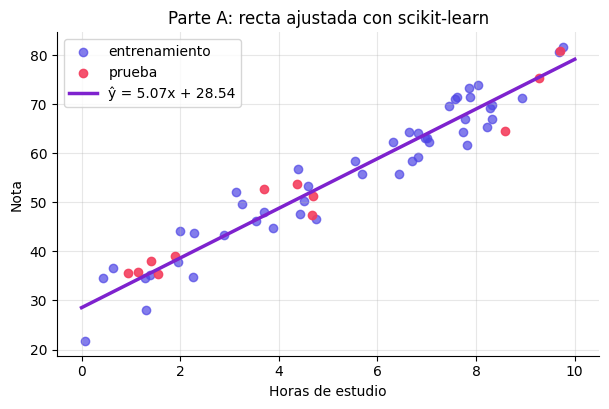

In [11]:
xs = np.linspace(0, 10, 100).reshape(-1, 1)
plt.scatter(X_train, y_train, color=INDIGO, alpha=0.7, label='entrenamiento')
plt.scatter(X_test, y_test, color=CORAL, alpha=0.9, label='prueba')
plt.plot(xs, modelo.predict(xs), color=PURPURA, lw=2.5,
label=f'ŷ = {w_sk:.2f}x + {b_sk:.2f}')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Parte A: recta ajustada con scikit-learn'); plt.legend()
plt.show()

In [12]:
def costo(w, b, x, y):
  """J(w, b) = (1/2m) Σ (w·x + b − y)²"""
  y_pred = w * x + b
  return np.mean((y_pred - y) ** 2) / 2

x_train, x_test = X_train.ravel(), X_test.ravel()

print(f'J(0, 0)  = {costo(0, 0, x_train, y_train):8.2f}  <- recta en 0')
print(f'J(5, 30) = {costo(5, 30, x_train, y_train):8.2f}  <- relación real')

J(0, 0)  =  1667.25  <- recta en 0
J(5, 30) =     7.88  <- relación real


In [13]:
def gradientes(w, b, x, y):
    """Devuelve (∂J/∂w, ∂J/∂b)."""
    error = (w * x + b) - y
    dw = np.mean(error * x)
    db = np.mean(error)
    return dw, db

dw, db = gradientes(0, 0, x_train, y_train)
print(f'En (w, b) = (0, 0):  ∂J/∂w = {dw:.2f},  ∂J/∂b = {db:.2f}')

En (w, b) = (0, 0):  ∂J/∂w = -339.86,  ∂J/∂b = -55.98


In [14]:
def descenso_gradiente(x, y, alpha=0.01, iteraciones=10_000):
    w, b = 0.0, 0.0
    historial = []

    for i in range(iteraciones):
        dw, db = gradientes(w, b, x, y)
        w = w - alpha * dw
        b = b - alpha * db
        historial.append(costo(w, b, x, y))

        if i in (0, 10, 100, 1000, iteraciones - 1):
            print(f'iter {i:>5}:  w = {w:7.4f}   b = {b:8.4f}'
                  f'   J = {historial[-1]:9.4f}')

    return w, b, historial

w_gd, b_gd, historial = descenso_gradiente(x_train, y_train,
                                           alpha=0.01, iteraciones=10_000)

iter     0:  w =  3.3986   b =   0.5598   J =  702.4903
iter    10:  w =  8.9765   b =   1.9226   J =   77.3678
iter   100:  w =  8.3954   b =   6.1889   J =   56.6861
iter  1000:  w =  5.6493   b =  24.6320   J =    8.7716
iter  9999:  w =  5.0675   b =  28.5394   J =    7.2610


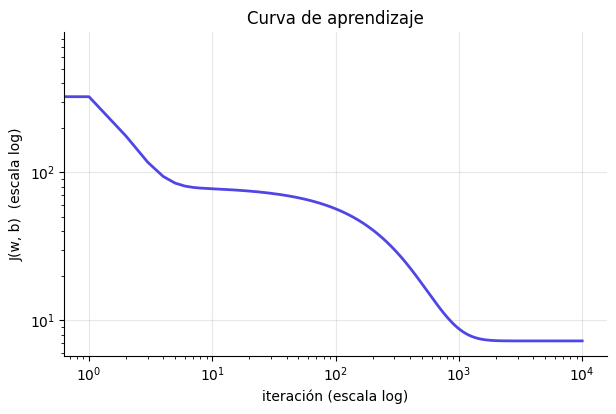

In [15]:
plt.plot(historial, color=INDIGO, lw=2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('iteración (escala log)'); plt.ylabel('J(w, b)  (escala log)')
plt.title('Curva de aprendizaje')
plt.show()

In [16]:
y_pred_gd = w_gd * x_test + b_gd

mae  = np.mean(np.abs(y_test - y_pred_gd))
rmse = np.sqrt(np.mean((y_test - y_pred_gd) ** 2))
r2   = 1 - (np.sum((y_test - y_pred_gd) ** 2)
            / np.sum((y_test - y_test.mean()) ** 2))

print(f'MAE  = {mae:.3f} puntos')
print(f'RMSE = {rmse:.3f} puntos')
print(f'R²   = {r2:.3f}')

MAE  = 2.781 puntos
RMSE = 3.491 puntos
R²   = 0.946


In [17]:
print(f'{"":22}{"w":>10}{"b":>10}')
print(f'{"Valor real":22}{5:>10.4f}{30:>10.4f}')
print(f'{"scikit-learn":22}{w_sk:>10.4f}{b_sk:>10.4f}')
print(f'{"Descenso de gradiente":22}{w_gd:>10.4f}{b_gd:>10.4f}')
print(f'\nDiferencia |w_sk − w_gd| = {abs(w_sk - w_gd):.2e}')
print(f'Diferencia |b_sk − b_gd| = {abs(b_sk - b_gd):.2e}')

                               w         b
Valor real                5.0000   30.0000
scikit-learn              5.0675   28.5394
Descenso de gradiente     5.0675   28.5394

Diferencia |w_sk − w_gd| = 1.55e-08
Diferencia |b_sk − b_gd| = 1.04e-07


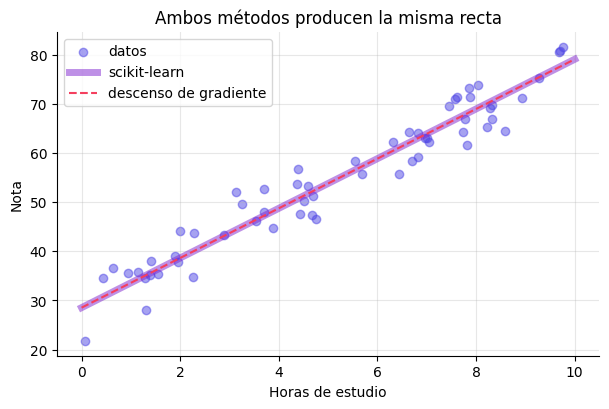

In [18]:
plt.scatter(horas, nota, color=INDIGO, alpha=0.5, label='datos')
plt.plot(xs, modelo.predict(xs), color=PURPURA, lw=5, alpha=0.5,
label='scikit-learn')
plt.plot(xs, w_gd * xs + b_gd, color=CORAL, lw=1.5, ls='--',
label='descenso de gradiente')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Ambos métodos producen la misma recta'); plt.legend()
plt.show()